In [7]:
from blackjack.blackjack_round import BJRound, BJStage, BJRules
from blackjack.actions import PlayerAction, DealerAction
from blackjack.cards import Card, Rank
import numpy as np
import time
import logging
from datetime import datetime
import os
from logging import FileHandler
import tqdm
from collections import deque
from blackjack.shoe import ProbabilisticRankShoe
import time
from blackjack.game_tree import BJTreeNode, MonteCarloNode
import datetime
import matplotlib.pyplot as plt

In [8]:
rules = BJRules(
    dealer_checks_blackjack=True,
    dealer_hits_soft_17=False,
    allow_late_surrender=False,
    allow_early_surrender_on_ten=False,
    allow_early_surrender_on_ace=False,
    allow_early_surrender_on_all=False,
    dealer_shows_card_on_surrender=False,
    allow_insurance_vs_ace=True,
    natural_blackjack_payout=3/2,
    surrender_payout=1/2,
    insurance_payout=2/1,
    max_splits_allowed=1,
    allow_action_on_split_aces=True,
    allow_double_after_split=True,
    allow_double_on_soft=True,
    allow_split_different_tens=True,
    no_natural_bj_on_split=True
)

In [10]:
def get_nodes_on_the_level(root_node, level):
    nodes = []
    queue = deque()
    queue.append((root_node, 0))
    while queue:
        node, node_level = queue.popleft()
        if node_level == level:
            nodes.append(node)
        elif node_level < level:
            for child in node.children:
                queue.append((child, node_level + 1))
    return nodes

In [40]:
main_actions_list = [
    PlayerAction.HIT,
    PlayerAction.STAND,
    PlayerAction.DOUBLE,
    PlayerAction.SPLIT
]


def best_action_hard_vs_dealer(hard_value, dealer_card):
    if hard_value < 5 or hard_value > 19:
        raise ValueError("Invalid hard value")

    if hard_value >= 12:
        player_card_0 = 10
    else:
        player_card_0 = 2
    
    player_card_1 = hard_value - player_card_0 

    cards = [
        Card(Rank.from_value(player_card_0)),
        Card(Rank.from_value(player_card_1)),
        Card(Rank.from_value(dealer_card))  
    ]
    
    bj_round = BJRound(rules)
    shoe = ProbabilisticRankShoe(8)
    bj_round.start_round(10)

    bj_round.take_card(cards[0])
    bj_round.take_card(cards[1])
    bj_round.take_card(cards[2])

    shoe.burn_rank_value(cards[0].rank_value())
    shoe.burn_rank_value(cards[1].rank_value())
    shoe.burn_rank_value(cards[2].rank_value())

    root_node = BJTreeNode(bj_round, shoe, monte_carlo_depth=6)
    root_node.build_tree()
    
    expected_value_0 = root_node.get_value()
    expected_value_1 = None

    main_action = None
    insurance_action = None
    action_node = root_node
    while main_action is None:
        stage = action_node.bj_round.get_stage()
        if stage == BJStage.DEALER_CHECK_BJ:
            # find branch where dealer doesn't have bj
            for ch in action_node.children:
                if ch.last_action == DealerAction.CONFIRM_NO_BLACKJACK:
                    action_node = ch
                    break
        elif stage == BJStage.PLAYER_OFFERED_INSURANCE:
            child_idx = np.argmax(action_node.children_prob)
            action_node = action_node.children[child_idx]
            insurance_action = action_node.last_action
        elif stage == BJStage.PLAYER_ACTION:
            action_child_idx = np.argmax(action_node.children_prob)
            after_action_node = action_node.children[action_child_idx]
            main_action = after_action_node.bj_round.last_action
            expected_value_1 = after_action_node.get_value()
        else:
            raise RuntimeError(f"Unexpected stage {stage}")
    
    return main_action, insurance_action, expected_value_0, expected_value_1

In [ ]:
action_data = {}

for hard in tqdm.tqdm(range(5, 20)):
    for dealer in range(2, 12):
        result = best_action_hard_vs_dealer(hard, dealer)
        action_data[(hard, dealer)] = result

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [16:32<?, ?it/s]


KeyboardInterrupt: 

In [43]:


actions_only = {k: v[0] for k, v in action_data.items()}

In [44]:
actions_only

{(5, 2): <PlayerAction.HIT: 'HIT'>,
 (5, 3): <PlayerAction.HIT: 'HIT'>,
 (5, 4): <PlayerAction.HIT: 'HIT'>,
 (5, 5): <PlayerAction.HIT: 'HIT'>,
 (5, 6): <PlayerAction.HIT: 'HIT'>}

In [45]:
action_data

{(5, 2): (<PlayerAction.HIT: 'HIT'>,
  None,
  np.float64(-1.1411391529512456),
  np.float64(-1.1411391529512456)),
 (5, 3): (<PlayerAction.HIT: 'HIT'>,
  None,
  np.float64(-0.7313434203017526),
  np.float64(-0.7313434203017526)),
 (5, 4): (<PlayerAction.HIT: 'HIT'>,
  None,
  np.float64(-0.4499393319375473),
  np.float64(-0.4499393319375473)),
 (5, 5): (<PlayerAction.HIT: 'HIT'>,
  None,
  np.float64(-0.06169429003163124),
  np.float64(-0.06169429003163124)),
 (5, 6): (<PlayerAction.HIT: 'HIT'>,
  None,
  np.float64(0.13198540695771147),
  np.float64(0.13198540695771147))}

In [ ]:
import os
import pickle

# Save action_data to a pickle file with a timestamp
_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = "logs"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"action_data_{_ts}.pkl")
with open(out_path, "wb") as f:
    pickle.dump(action_data, f, protocol=pickle.HIGHEST_PROTOCOL)

actions_only_path = os.path.join(out_dir, f"actions_only_{_ts}.pkl")
with open(actions_only_path, "wb") as f:
    pickle.dump(actions_only, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved action_data with {len(action_data)} entries to {out_path}")

# Quick sanity check (optional)
with open(out_path, "rb") as f:
    _loaded = pickle.load(f)
print(f"Reloaded ok. Sample key: {next(iter(_loaded)) if _loaded else 'n/a'}")

with open(actions_only_path, "rb") as f:
    _loaded_actions_only = pickle.load(f)       
print(
    f"Reloaded actions_only ok. ",
    f"Sample key: {next(iter(_loaded_actions_only)) if _loaded_actions_only else 'n/a'}"
)

SyntaxError: incomplete input (112134975.py, line 24)

In [36]:
_loaded

{(5, 2): (<PlayerAction.HIT: 'HIT'>,
  None,
  np.float64(-0.38338465878370453),
  np.float64(-0.38338465878370453))}

In [11]:
bj_round = BJRound(rules)
shoe = ProbabilisticRankShoe(8)
bj_round.start_round(10)

cards = [
    Card(Rank.ACE),
    Card(Rank.ACE),
    Card(Rank.SIX)  
]

# cards = [
#     Card(Rank.TEN),
#     Card(Rank.SIX),
#     Card(Rank.ACE)  
# ]

bj_round.take_card(cards[0])
bj_round.take_card(cards[1])
bj_round.take_card(cards[2])

shoe.burn_rank_value(cards[0].rank_value())
shoe.burn_rank_value(cards[1].rank_value())
shoe.burn_rank_value(cards[2].rank_value())

root_node = BJTreeNode(bj_round, shoe, monte_carlo_depth=7)

print(str(bj_round))

Last card: 6.
Dealer 6.X
Player A.A.(12/2)[$10]


In [12]:
for i in range(50):
    t0 = time.time()
    root_node.build_tree_layer(depth=i)
    t1 = time.time()
    dt = datetime.timedelta(seconds=t1 - t0)
    print(f"Depth {i} built in {dt}")
    if root_node.tree_completed():
        print("Tree completed")
        break

Depth 0 built in 0:00:00.000007
Depth 1 built in 0:00:00.000607
Depth 2 built in 0:00:00.007297
Depth 3 built in 0:00:00.057022
Depth 4 built in 0:00:00.234828
Depth 5 built in 0:00:01.783843
Depth 6 built in 0:00:03.102664
Depth 7 built in 0:00:17.016180
Depth 8 built in 0:19:28.342165
Depth 9 built in 0:06:13.306159
Depth 10 built in 0:06:04.197118
Depth 11 built in 0:08:20.878721
Depth 12 built in 0:07:40.481202
Depth 13 built in 0:06:04.632909
Depth 14 built in 0:05:08.131438
Depth 15 built in 0:03:44.470462
Depth 16 built in 0:02:39.502990
Depth 17 built in 0:01:51.631470
Depth 18 built in 0:01:07.428354
Depth 19 built in 0:00:38.843895
Depth 20 built in 0:00:21.604175
Depth 21 built in 0:00:11.039145
Depth 22 built in 0:00:05.863442
Depth 23 built in 0:00:02.274190
Depth 24 built in 0:00:01.153275
Depth 25 built in 0:00:00.235945
Depth 26 built in 0:00:00.135206
Depth 27 built in 0:00:00.033172
Tree completed


In [13]:
print(root_node.get_value())

12.52295188393343


100%|██████████| 1000/1000 [04:44<00:00,  3.52it/s]


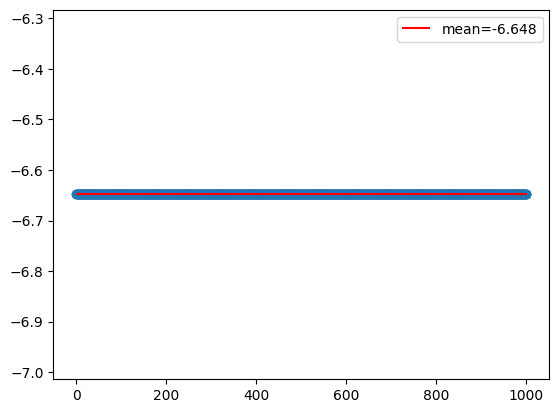

In [ ]:
values = []

values.append(root_node.get_value())

for i in tqdm.tqdm(range(1000)):
    root_node.resample_player_cards()
    values.append(root_node.get_value())
mean_value = np.mean(values)

f, ax = plt.subplots()
ax.scatter(range(len(values)), values)
ax.hlines(mean_value, xmin=0, xmax=len(values), color="red", label=f"mean={mean_value:.3f}")
ax.legend()

In [15]:
print(root_node.get_value())
print(root_node.children_prob)
print([f"{ch.get_value():.2f}" for ch in root_node.children])

12.52295188393343
[0, 0, 0, 1]
['-1.48', '2.11', '1.88', '12.52']


In [16]:
np.min(values), np.max(values)

NameError: name 'values' is not defined

In [ ]:
values = []

values.append(root_node.get_value())

for i in tqdm.tqdm(range(1000)):
    root_node.resample_player_cards()
    values.append(root_node.get_value())
mean_value = np.mean(values)


100%|██████████| 1000/1000 [04:58<00:00,  3.35it/s]


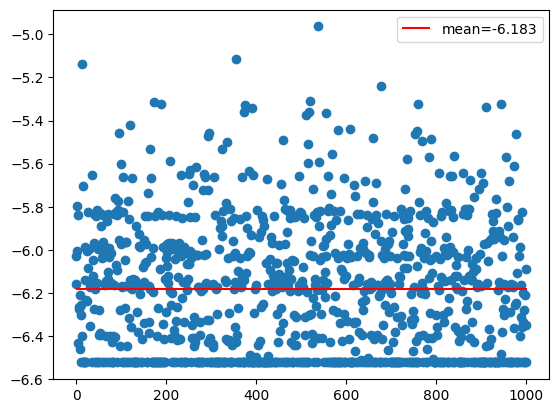

In [ ]:
f, ax = plt.subplots()
ax.scatter(range(len(values)), values)
ax.hlines(mean_value, xmin=0, xmax=len(values), color="red", label=f"mean={mean_value:.3f}")
ax.legend()

In [ ]:
np.min(values), np.max(values)

(np.float64(-6.5221443851524485), np.float64(-4.963786172688591))

In [17]:
for lvl in range(25):
    level_nodes = get_nodes_on_the_level(root_node, lvl)
    print(f"Level {lvl} has {len(level_nodes)} nodes")
    finished = False
    for n in level_nodes:
        if n.bj_round.get_stage() == BJStage.ROUND_OVER:
            continue
        elif isinstance(n, MonteCarloNode):
            print(f"MonteCarloNode found on level {lvl}")
            finished = True
            break
        else:
            break
    
    if finished:
        break

Level 0 has 1 nodes
Level 1 has 4 nodes
Level 2 has 40 nodes
Level 3 has 318 nodes
Level 4 has 1807 nodes
Level 5 has 7753 nodes
Level 6 has 23855 nodes
Level 7 has 109879 nodes
MonteCarloNode found on level 7


In [18]:
from collections import Counter
count = Counter()

player_card_nodes = []
player_action_nodes = []
for node in level_nodes:
    stage = node.bj_round.get_stage()
    count[stage] += 1
    if stage == BJStage.PLAYER_CARD:
        player_card_nodes.append(node)
    if stage == BJStage.PLAYER_ACTION:
        player_action_nodes.append(node)



In [19]:
count

Counter({<BJStage.DEALER_CARD: 7>: 47273,
         <BJStage.ROUND_OVER: 8>: 43470,
         <BJStage.PLAYER_ACTION: 4>: 16437,
         <BJStage.PLAYER_CARD: 5>: 2699})

In [20]:
for i, n in enumerate(player_action_nodes):
    print(f"idx = {i}")
    print(f"Value = {n.get_value()}")
    print(str(n.bj_round))
    print()

idx = 0
Value = 26.2
Last card: 2.
Dealer 6.X
Player A.2.2.2.(17/7)[$10] | A.2.(13/3)[$10]

idx = 1
Value = 5.8
Last card: 3.
Dealer 6.X
Player A.2.2.3.(18/8)[$10] | A.2.(13/3)[$10]

idx = 2
Value = 9.1
Last card: 4.
Dealer 6.X
Player A.2.2.4.(19/9)[$10] | A.2.(13/3)[$10]

idx = 3
Value = 17.0
Last card: 5.
Dealer 6.X
Player A.2.2.5.(20/10)[$10] | A.2.(13/3)[$10]

idx = 4
Value = 21.9
Last card: 6.
Dealer 6.X
Player A.2.2.6.(21/11 - stand)[$10] | A.2.(13/3)[$10]

idx = 5
Value = 16.4
Last card: 7.
Dealer 6.X
Player A.2.2.7.(12)[$10] | A.2.(13/3)[$10]

idx = 6
Value = 9.6
Last card: 8.
Dealer 6.X
Player A.2.2.8.(13)[$10] | A.2.(13/3)[$10]

idx = 7
Value = 4.0
Last card: 9.
Dealer 6.X
Player A.2.2.9.(14)[$10] | A.2.(13/3)[$10]

idx = 8
Value = -1.6
Last card: T.
Dealer 6.X
Player A.2.2.T.(15)[$10] | A.2.(13/3)[$10]

idx = 9
Value = 10.2
Last card: A.
Dealer 6.X
Player A.2.2.A.(16/6)[$10] | A.2.(13/3)[$10]

idx = 10
Value = 16.8
Last card: 2.
Dealer 6.X
Player A.2.3.2.(18/8)[$10] | A.2.(1

In [21]:
this_node = player_card_nodes[-1].parent
this_node.build_tree()

print(f"this_node Value = {this_node.get_value()}")
print(str(this_node.bj_round))
first_value = this_node.get_value()

this_node Value = 9.7
Last action: STAND
Dealer 6.X
Player A.A.A.(13/3 - stand)[$10] | A.A.(12/2)[$10]


In [22]:
for i in range(100):
    changed = this_node.resample_player_cards()
    if this_node.get_value() == first_value:
        continue
    print(changed, this_node.get_value())
    print("-" * 32)

    # for i in range(len(this_node.children)):
    #     p = this_node.children_prob[i]
    #     ch = this_node.children[i]
    #     print(f"Value = {ch.get_value()}")
    #     print(f"Probability = {p}")
    #     print(str(ch.bj_round))
    #     print()
    # print("-" * 32)


True 6.0
--------------------------------
True -1.2
--------------------------------
True -3.6
--------------------------------
True 2.2
--------------------------------
True -2.4
--------------------------------
True 4.6
--------------------------------
True 7.4
--------------------------------
True 0.0
--------------------------------
 6.0
--------------------------------
True -1.2
--------------------------------
True -3.6
--------------------------------
True 2.2
--------------------------------
True -2.4
--------------------------------
True 4.6
--------------------------------
True 7.4
--------------------------------
True 0.0
--------------------------------
True 6.8
--------------------------------
True 6.9
--------------------------------
True -2.0
--------------------------------
True 9.6
--------------------------------
True 10.2
--------------------------------
True 9.1
--------------------------------
True 6.8
--------------------------------
True 6.9
---------------------

In [23]:
# this_node.has_completed_tree = False
# this_node.has_built_children = False
# this_node.children_prob = []
# this_node.children = []

In [24]:
print(this_node.children[1].children[-1].bj_round)

Last card: T.
Dealer 6.X
Player A.A.A.(13/3 - stand)[$10] | A.A.T.(12)[$10]


In [25]:
for i in range(100):
    this_node.resample_player_cards()
    children_of_interest = this_node.children[1].children[-1].children

    # if this_node.children_prob[1] == 0:
    #    continue
    
    # print(this_node.get_value())
    # print([f"{ch.get_value():.2f}" for ch in this_node.children])
    print(this_node.children_prob)

[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]
[0, 1, 0]
[0, 1, 0]
[0, 1, 0]
[0, 0, 1]


In [26]:
this_node.resample_player_cards()

for ch in this_node.children:
    print(ch.get_value())
    print(str(ch.bj_round))
    print()

-4.4
Last action: STAND
Dealer 6.X
Player A.A.A.(13/3 - stand)[$10] | A.A.(12/2 - stand)[$10]

-1.2
Last action: HIT
Dealer 6.X
Player A.A.A.(13/3 - stand)[$10] | A.A.(12/2)[$10]

1.2
Last action: DOUBLE
Dealer 6.X
Player A.A.A.(13/3 - stand)[$10] | A.A.(12/2)[$20]



In [27]:

print(this_node.children[0].get_value())

-4.4


In [28]:
print(this_node.children)

[<blackjack.game_tree.MonteCarloNode object at 0x78027b4527b0>, <blackjack.game_tree.MonteCarloNode object at 0x78027b452990>, <blackjack.game_tree.MonteCarloNode object at 0x78027b452b70>]
